In [60]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import h5py
import torch.optim as optim

In [61]:
file = h5py.File("train_catvnoncat.h5","r")

In [62]:
print(list(file))

['list_classes', 'train_set_x', 'train_set_y']


In [63]:
file["train_set_x"].shape

(209, 64, 64, 3)

In [64]:
array = np.array(file["train_set_x"])

In [65]:
train_set_x_flatten = array.reshape(len(file["train_set_x"]), 64*64*3)

In [66]:
train_set_x_flatten_transposed = train_set_x_flatten.transpose()

In [67]:
train_set_x_flatten_transposed = train_set_x_flatten_transposed/255.

In [68]:
array_y = np.array(file["train_set_y"]).reshape(1,len(file["train_set_y"]))

In [69]:
w = np.zeros((64*64*3,1))
b = np.zeros(())

In [70]:
z = np.dot(w.T,train_set_x_flatten_transposed)+b

In [71]:
def segmoid(z):
    return 1/(1+np.exp(-z))

In [72]:
A = segmoid(z)

In [73]:
m = train_set_x_flatten_transposed.shape[1]

In [74]:
J = (-1/m) * np.sum((array_y*np.log(A))+((1-array_y)*(np.log(1-A))))


In [75]:
dw = (1/m)*np.dot(train_set_x_flatten_transposed,(A - array_y).T)
db = (1/m)*np.sum(A-array_y)

In [76]:
w = w - np.dot(0.01,dw)
b = b - np.dot(0.01,db)

In [77]:
print (w)

[[-0.00047209]
 [-0.00062998]
 [-0.00049235]
 ...
 [-0.00050746]
 [-0.00062126]
 [-0.00032451]]


In [78]:
Y_hat = (A>0.5)

In [79]:
Y_hat = Y_hat.astype(int)

In [80]:
for i in range(1000):
    z = np.dot(w.T,train_set_x_flatten_transposed)+b
    A=segmoid(z)
    J = (-1/m) * np.sum((array_y*np.log(A))+((1-array_y)*(np.log(1-A))))
    dw = (1/m)*np.dot(train_set_x_flatten_transposed,(A - array_y).T)
    db = (1/m)*np.sum(A-array_y)
    w = w - np.dot(0.01,dw)
    b = b - np.dot(0.01,db)
    if i%100 ==0:
        print(J)

1.120173947456166


1.9230473939961954
0.6787412907442172
1.0160548433710777
0.7153096520076523
0.45512468890992863
0.24482031468557788
0.15403407881883113
0.13520977358292757
0.12487895325332939


In [81]:
X_images = np.array(file["train_set_x"])

In [82]:
Y_hat = (A>0.5)

In [83]:
Y_hat = Y_hat.astype(int)

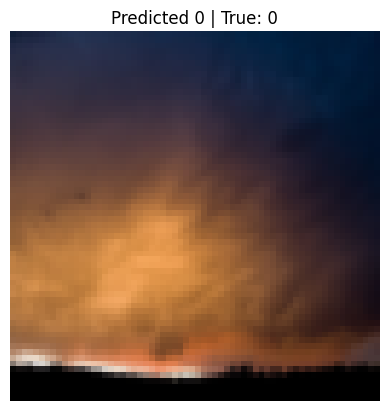

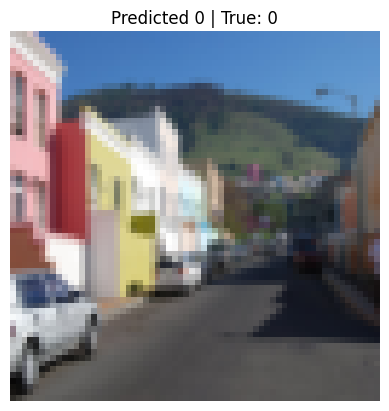

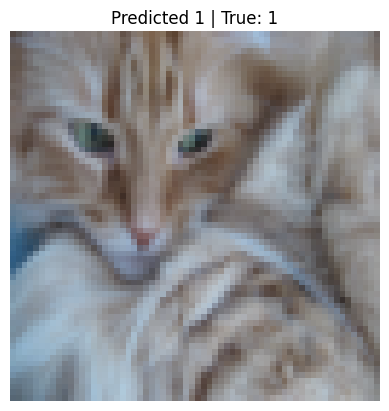

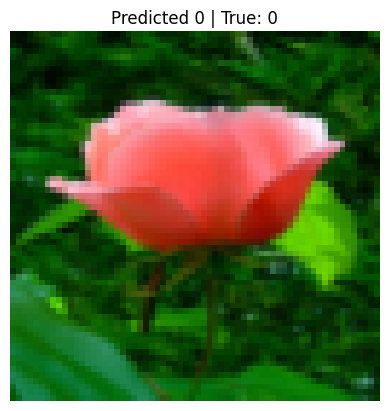

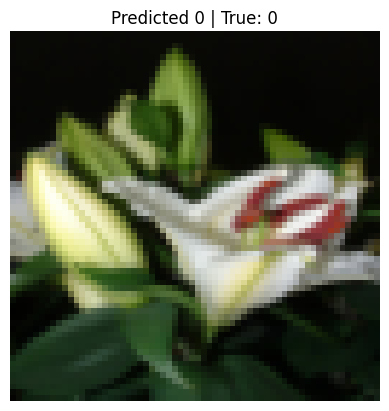

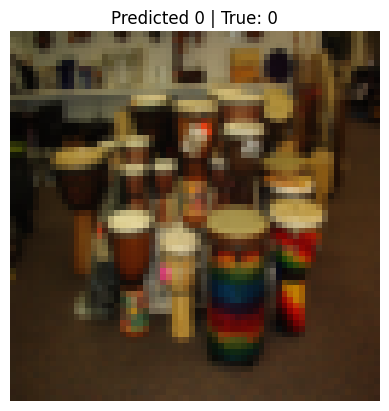

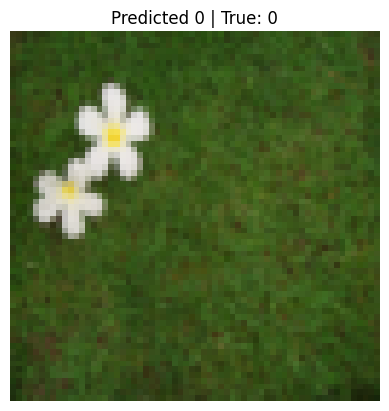

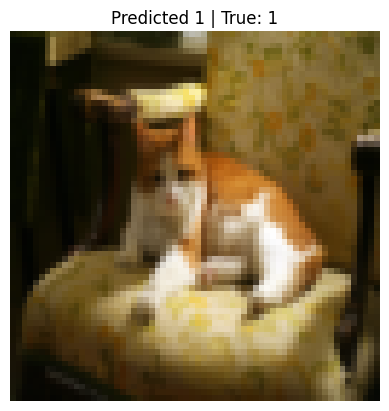

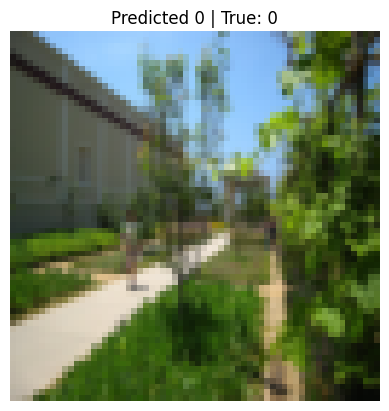

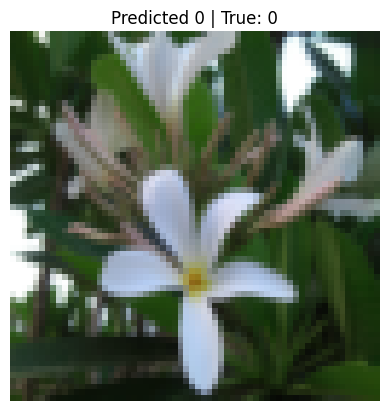

In [84]:
for i in range(10):
    plt.imshow(X_images[i])
    plt.axis("off")
    plt.title(f"Predicted {Y_hat[0,i]} | True: {array_y[0,i]}")
    plt.show()

In [85]:
accuracy = 100 * np.mean(Y_hat == array_y)
print(accuracy)

98.56459330143541
